# Proposed Model — CEDAR Split Evaluation

DenseNet-121 + CBAM (post-block / pre-transition) trained in two steps:

| Step | Method | Epochs |
|---|---|---|
| 1 — Pretraining | TripletLoss (Euclidean, hard-negative mining) | 30 |

Combined total = **100 epochs**, matching the baseline budget exactly.

| | |
|---|---|
| **Dataset** | CEDAR |
| **Split** | 70:15:15 |

**Prerequisite:** run `scripts/prepare_split_ratios.py` to generate split JSONs.

## Step 1 — Imports & Reproducibility

In [1]:
import os, sys, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
import seaborn as sns
 
REPO_ROOT = os.path.abspath(os.path.join(os.path.abspath(os.getcwd()), '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)
 
from models.feature_extractor                  import DenseNetFeatureExtractor
from models.Triplet_Siamese_Similarity_Network import tDCBAM
from losses.triplet_loss                       import TripletLoss
from utils.model_evaluation                    import (compute_metrics, _plot_det_curve,
                                                        _plot_far_frr, _plot_confusion_matrix,
                                                        _plot_score_distribution, _plot_roc_curve)
from dataloader.tDCBAM_trainloader import get_transforms, sample_augment_params, preprocess_image
 
 
def seed_everything(seed=42):
    """Seed all random sources for full reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" > [Seed] {seed}")
 
 
seed_everything(42)
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [Device] {DEVICE}" +
      (f"  ({torch.cuda.get_device_name()})" if torch.cuda.is_available() else ""))

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [Seed] 42
 > [Device] cuda  (NVIDIA GeForce RTX 5080)


## Step 2 — Configuration

In [2]:
NOTEBOOK_NAME = 'tDCBAM_bengali'
DATASET       = 'bhsig_bengali'
DATASET_NAME  = 'BHSig-Bengali'
 
SPLIT_DIR      = os.path.join(REPO_ROOT, 'data',        'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'proposed_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals',  NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,       exist_ok=True)
 
SPLIT_RATIOS = ['70_15_15']
 
IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)
NUM_WORKERS = 4
 
TRAIN_EPOCHS        = 100
TRAIN_PHASE1_EPOCHS = 20
TRAIN_LR            = 1e-4
TRAIN_MARGIN        = 1.0
TRAIN_WEIGHT_DECAY  = 1e-4
TRAIN_BATCH_SIZE    = 32
 
FEATURE_DIM   = 1024
EMBEDDING_DIM = 1024
 
print(f" > [Config] Epochs: {TRAIN_EPOCHS} (P1 frozen: {TRAIN_PHASE1_EPOCHS})")
print(f" > [Config] LR: {TRAIN_LR} | Margin: {TRAIN_MARGIN} | "
      f"WD: {TRAIN_WEIGHT_DECAY} | Batch: {TRAIN_BATCH_SIZE}")

 > [Config] Epochs: 100 (P1 frozen: 20)
 > [Config] LR: 0.0001 | Margin: 1.0 | WD: 0.0001 | Batch: 32


## Step 3 — Transforms

In [3]:
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)
 
print(" > [Transforms] train_transform: augmentation ON  (geometric)")
print(" > [Transforms] val_transform  : augmentation OFF (preprocessing only)")

 > [Transforms] train_transform: augmentation ON  (geometric)
 > [Transforms] val_transform  : augmentation OFF (preprocessing only)


## Step 4 — Datasets

In [4]:
class SplitImageDataset(Dataset):
    """
    Flat image-label dataset for online triplet mining.

    Returns individual (image_tensor, writer_id_int) pairs.
    No triplet pre-generation — triplets are mined online inside
    OnlineTripletLoss using the BalancedBatchSampler's structured batches.

    The writer_id is encoded as a contiguous integer (0, 1, 2, ...) for
    compatibility with the BalancedBatchSampler's label grouping.

    Args:
        user_dict   (dict)    : {uid: {'genuine': [...paths], 'forged': [...]}}
        input_shape (tuple)   : Canvas size for preprocess_image.
        training    (bool)    : True → augmentation ON. False → no augmentation.
        transform   (callable): Val transform (used when training=False).
    """

    def __init__(self, user_dict, input_shape=(224, 224),
                 training=True, transform=None):
        self.input_shape = input_shape
        self.training    = training
        self.transform   = transform

        self.samples = []   # list of (path, label_int)
        self.labels  = []   # parallel list of label_int, for BalancedBatchSampler

        # Encode writer UIDs as contiguous integers
        uid_to_int = {uid: i for i, uid in enumerate(user_dict.keys())}

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')), None)
            gen_paths = data.get(gen_key, []) if gen_key else []

            label_int = uid_to_int[uid]
            for path in gen_paths:
                self.samples.append((path, label_int))
                self.labels.append(label_int)

        n_writers = len(uid_to_int)
        n_samples = len(self.samples)
        mode_label = "aug ON" if training else "aug OFF"
        print(f"   ImageDataset: {n_samples} images | "
              f"{n_writers} writers | {mode_label}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')

        if self.training:
            tensor = preprocess_image(img, img_size=self.input_shape, augment=True)
        else:
            if self.transform:
                tensor = self.transform(img)
            else:
                tensor = preprocess_image(img, img_size=self.input_shape, augment=False)

        return tensor, torch.tensor(label, dtype=torch.long)
 
class SplitPairDataset(Dataset):
    """
    Pairwise dataset for validation and test evaluation.
 
    Builds (support, query, label) pairs where:
        label = 1  →  both images are genuine (same writer)
        label = 0  →  support is genuine, query is a skilled forgery
 
    For each writer:
        - Genuine pairs  : all C(n_genuine, 2) combinations
        - Forgery pairs  : genuine[i] paired with each forged sample
 
    Args:
        user_dict    (dict)     : {uid: {'genuine': [...paths], 'forged': [...paths]}}
        input_shape  (tuple)    : Canvas size for preprocess_image. Default (224, 224).
        transform    (callable) : Validation transform (no augmentation).
    """
 
    def __init__(self, user_dict, input_shape=(224, 224), transform=None):
        self.input_shape = input_shape
        self.transform   = transform
        self.pairs       = []
 
        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')),              None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []
 
            # Genuine–Genuine pairs (label = 1)
            for i in range(len(gen_paths)):
                for j in range(i + 1, len(gen_paths)):
                    self.pairs.append((gen_paths[i], gen_paths[j], 1))
 
            # Genuine–Forged pairs (label = 0)
            for g_path in gen_paths:
                for f_path in forg_paths:
                    self.pairs.append((g_path, f_path, 0))
 
        print(f"   PairDataset: {len(self.pairs)} pairs "
              f"({sum(1 for _,_,l in self.pairs if l==1)} genuine, "
              f"{sum(1 for _,_,l in self.pairs if l==0)} forged)")
 
    def __len__(self):
        return len(self.pairs)
 
    def __getitem__(self, idx):
        sup_path, qry_path, label = self.pairs[idx]
        sup_img = self._load(sup_path)
        qry_img = self._load(qry_path)
        return sup_img, qry_img, torch.tensor(label, dtype=torch.float32)
 
    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            return self.transform(img)
        return preprocess_image(img, img_size=self.input_shape, augment=False)

class BalancedBatchSampler(torch.utils.data.Sampler):
    """
    Balanced batch sampler for online triplet mining.

    Constructs each batch by sampling exactly P writers, then K images
    per writer, giving a batch of size P × K. This guarantees that every
    batch contains multiple samples per writer, which is the structural
    requirement for online hard triplet mining to find meaningful positives.

    If a writer has fewer than K genuine images, samples with replacement
    for that writer only.

    Args:
        labels      (list[int]): Writer ID label for every sample in the dataset.
        P           (int)      : Number of writers per batch. Default 8.
        K           (int)      : Samples per writer per batch. Default 4.
        num_batches (int)      : Number of batches per epoch.
                                 Defaults to len(dataset) // (P * K).
    """

    def __init__(self, labels, P=8, K=4, num_batches=None):
        self.P = P
        self.K = K

        # Group sample indices by writer ID
        self.label_to_indices = {}
        for idx, label in enumerate(labels):
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)

        self.writers = list(self.label_to_indices.keys())
        assert len(self.writers) >= P, (
            f"BalancedBatchSampler requires at least P={P} writers, "
            f"but only {len(self.writers)} available."
        )

        self.batch_size  = P * K
        self.num_batches = num_batches or (len(labels) // self.batch_size)

    def __iter__(self):
        for _ in range(self.num_batches):
            batch_indices = []

            # Sample P writers without replacement
            selected_writers = random.sample(self.writers, self.P)

            for writer in selected_writers:
                indices = self.label_to_indices[writer]
                if len(indices) >= self.K:
                    chosen = random.sample(indices, self.K)
                else:
                    # Sample with replacement only if writer has too few samples
                    chosen = random.choices(indices, k=self.K)
                batch_indices.extend(chosen)

            yield batch_indices

    def __len__(self):
        return self.num_batches


## Step 5 — Data Preview


 > [Viz] Preview using split '70_15_15'
   ImageDataset: 1680 images | 70 writers | aug ON


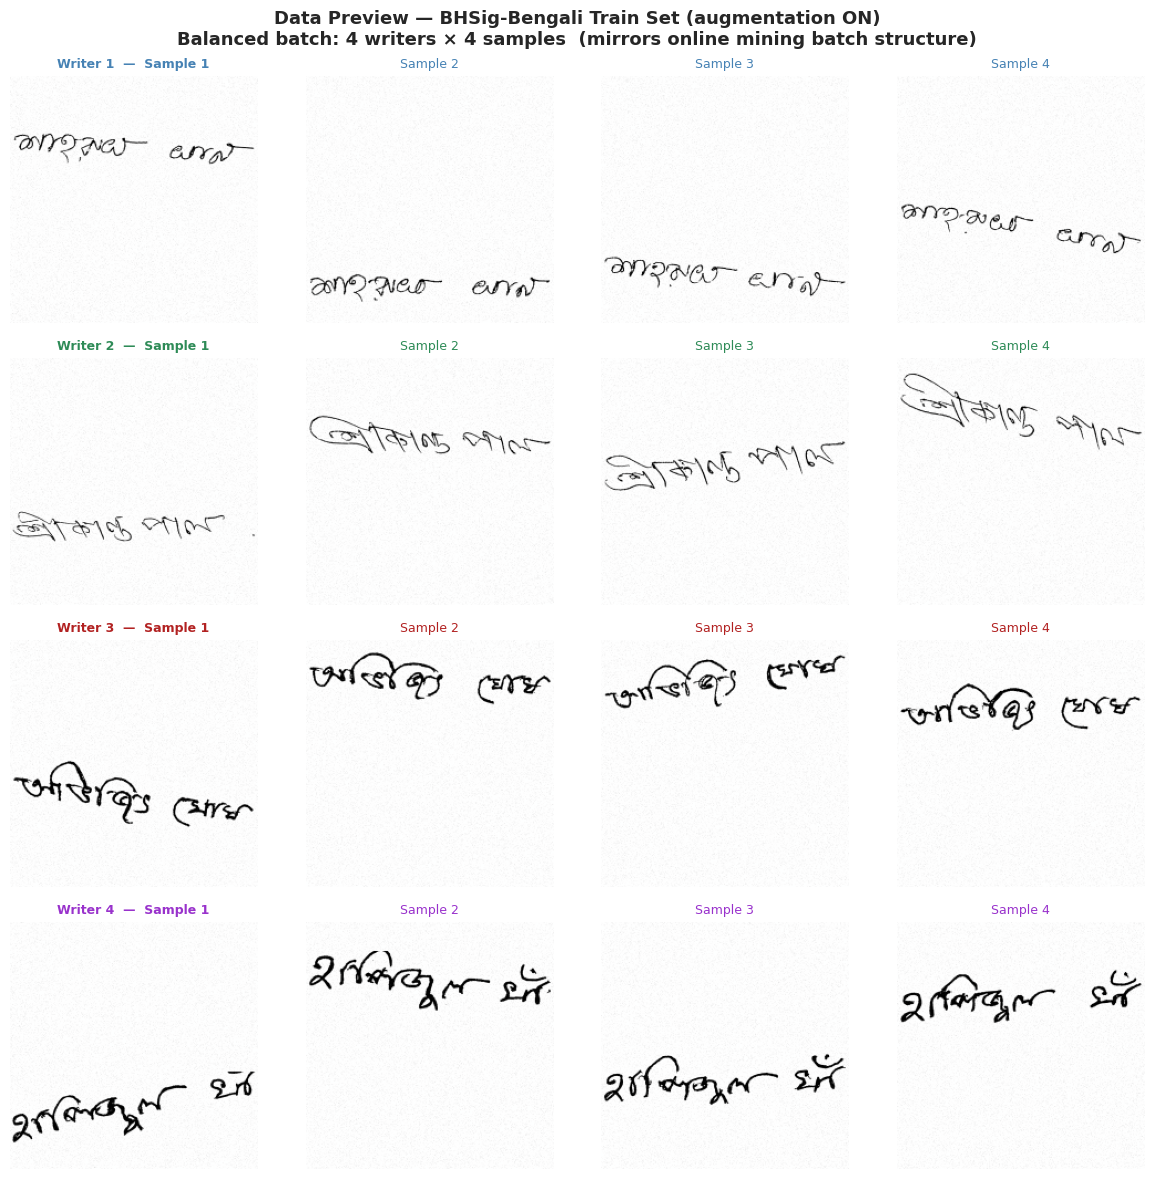

 > [Viz] Displayed 4 writers × 4 samples (16 images total)
 > [Viz] Label distribution: {'W1': 4, 'W2': 4, 'W3': 4, 'W4': 4}


In [5]:
def _unnorm(t):
    """Undo ImageNet normalisation for display. Returns H×W×C numpy in [0, 1]."""
    img  = t.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)


# ── Load split file ───────────────────────────────────────────────────────────
_prev_data = None
for _r in SPLIT_RATIOS:
    _f = os.path.join(SPLIT_DIR, f"{DATASET}_split_{_r}.json")
    if os.path.exists(_f):
        with open(_f) as _fh:
            _prev_data = json.load(_fh)
        print(f" > [Viz] Preview using split '{_r}'")
        break

if _prev_data is None:
    print(" > [Viz] No split file found — run prepare_split_ratios.py first")
else:
    # ── Preview config ────────────────────────────────────────────────────────
    # Show P_PREV writers × K_PREV samples — mirrors the actual training batch
    # structure so this cell verifies exactly what the online miner receives.
    P_PREV = 4   # writers to display (subset of training P=8 for readability)
    K_PREV = 4   # samples per writer (matches training K=4)

    # ── Dataset + BalancedBatchSampler ────────────────────────────────────────
    _ds = SplitImageDataset(
        _prev_data['train'],
        input_shape=INPUT_SHAPE,
        training=True,    # augmentation ON — shows exactly what training sees
        transform=None
    )

    _sampler = BalancedBatchSampler(
        labels=_ds.labels,
        P=P_PREV,
        K=K_PREV,
        num_batches=1     # only need one batch for preview
    )

    _loader = DataLoader(
        _ds,
        batch_sampler=_sampler,
        num_workers=0     # num_workers=0 for preview to avoid worker overhead
    )

    # ── Fetch one structured batch ────────────────────────────────────────────
    _images, _labels = next(iter(_loader))
    # _images: [P_PREV * K_PREV, C, H, W]
    # _labels: [P_PREV * K_PREV]  — contiguous writer IDs

    # ── Recover unique writers in batch-order ─────────────────────────────────
    # torch.unique with return_inverse gives us the order writers first appeared,
    # which matches the BalancedBatchSampler's grouping order.
    _unique_labels, _inverse = torch.unique(_labels, return_inverse=True)
    _n_writers = len(_unique_labels)

    # ── Plot: rows = writers, cols = samples ──────────────────────────────────
    fig, axes = plt.subplots(
        _n_writers, K_PREV,
        figsize=(K_PREV * 3, _n_writers * 3)
    )
    fig.suptitle(
        f"Data Preview — {DATASET_NAME} Train Set (augmentation ON)\n"
        f"Balanced batch: {_n_writers} writers × {K_PREV} samples  "
        f"(mirrors online mining batch structure)",
        fontsize=13, fontweight='bold'
    )

    # Consistent color per writer row
    _row_colors = ['steelblue', 'seagreen', 'firebrick', 'darkorchid',
                   'darkorange', 'teal', 'crimson', 'slategray']

    for _w_idx, _uid in enumerate(_unique_labels.tolist()):
        # Find all sample positions in the batch that belong to this writer
        _sample_indices = (_labels == _uid).nonzero(as_tuple=True)[0].tolist()
        _color = _row_colors[_w_idx % len(_row_colors)]

        for _k_idx, _s_idx in enumerate(_sample_indices[:K_PREV]):
            _ax = axes[_w_idx, _k_idx] if _n_writers > 1 else axes[_k_idx]
            _ax.imshow(_unnorm(_images[_s_idx]))
            _ax.axis('off')

            # Label only the first column with writer index
            if _k_idx == 0:
                _ax.set_title(
                    f"Writer {_w_idx + 1}  —  Sample {_k_idx + 1}",
                    fontsize=9, color=_color, fontweight='bold'
                )
            else:
                _ax.set_title(
                    f"Sample {_k_idx + 1}",
                    fontsize=9, color=_color
                )

    plt.tight_layout()
    plt.show()
    print(f" > [Viz] Displayed {_n_writers} writers × {K_PREV} samples "
          f"({_n_writers * K_PREV} images total)")
    print(f" > [Viz] Label distribution: "
          f"{dict(zip([f'W{i+1}' for i in range(_n_writers)], [K_PREV]*_n_writers))}")

## Step 6 — Training Utilities

In [6]:

# ── Backbone freeze / unfreeze ────────────────────────────────────────────────
def freeze_backbone(fe):
    """Freeze all backbone parameters (DenseNet-121 weights)."""
    for p in fe.get_backbone_params():
        p.requires_grad = False
 
 
def unfreeze_backbone(fe):
    """Unfreeze all model parameters for full fine-tuning."""
    for p in fe.parameters():
        p.requires_grad = True
 
 
# ── Distance-based validation ─────────────────────────────────────────────────
def validate(fe, loader, device):
    """
    Evaluates the feature extractor using pairwise Euclidean distance
    on the unit hypersphere.
 
    For each (support, query) pair:
        - Computes SED on L2-normalized embeddings (range [0, 4])
        - Converts to similarity score in [0, 1] (higher = more similar)
        - Passes scores and labels to compute_metrics for EER, AUC, etc.
 
    Args:
        fe     (DenseNetFeatureExtractor): Feature extractor in eval mode.
        loader (DataLoader)              : Pairwise validation/test loader.
        device (torch.device)            : Target device.
 
    Returns:
        dict: Metrics from compute_metrics (eer, auc, accuracy, f1, etc.)
    """
    fe.eval()
    all_scores, all_labels = [], []
 
    with torch.no_grad():
        for sup_imgs, qry_imgs, labels in loader:
            sup_imgs = sup_imgs.to(device, non_blocking=True)
            qry_imgs = qry_imgs.to(device, non_blocking=True)
            labels   = labels.to(device, non_blocking=True)
 
            sup_feat = fe(sup_imgs)   # [B, 1024], L2-normalised
            qry_feat = fe(qry_imgs)   # [B, 1024], L2-normalised
 
            # Squared Euclidean Distance on unit sphere, range [0, 4]
            distances = torch.sum((sup_feat - qry_feat) ** 2, dim=1)
 
            # Convert to similarity: higher score = more similar = more genuine
            scores = 1.0 - (distances / 4.0)   # range [0, 1]
 
            all_scores.extend(scores.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
 
    return compute_metrics(all_labels, all_scores)
 
 
# ── Final evaluation with plots ───────────────────────────────────────────────
def evaluate_model(fe, loader, device, output_dir=None, silent=False):
    """
    Runs validate() and optionally prints results and saves evaluation plots.
 
    Args:
        fe         (DenseNetFeatureExtractor): Feature extractor.
        loader     (DataLoader)              : Test loader.
        device     (torch.device)            : Target device.
        output_dir (str, optional)           : Directory to save plots.
        silent     (bool)                    : Suppress print output.
 
    Returns:
        dict: Metrics dictionary.
    """
    metrics = validate(fe, loader, device)
 
    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        for k, fmt in [('eer',       ':.2%'),
                       ('auc',       ':.4f'),
                       ('threshold', ':.4f'),
                       ('accuracy',  ':.2%'),
                       ('precision', ':.2%'),
                       ('recall',    ':.2%'),
                       ('f1',        ':.2%')]:
            print(f"  {k.upper():<13}: {metrics.get(k, 0):{fmt[1:]}}")
        print("=" * 38)
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)
 
    return metrics
 
 
def run_training(train_user_dict, val_user_dict, test_user_dict,
                 device, checkpoint_path,
                 epochs, phase1_epochs, lr,
                 margin, weight_decay, batch_size,
                 P=8, K=4,
                 output_dir=None):
    """
    Complete two-phase triplet training with online batch hard mining.

    Batch construction:
        BalancedBatchSampler samples P writers × K images per batch.
        P=8, K=4 → batch_size=32 by default (matches TRAIN_BATCH_SIZE).

    Loss:
        OnlineTripletLoss mines hardest positive and hardest negative
        per anchor within each structured batch.

    All other training logic (phase transition, differential LRs,
    ReduceLROnPlateau, periodic validation, checkpoint saving) is
    identical to the offline version.

    Args:
        ...same as before...
        P (int): Writers per batch for BalancedBatchSampler. Default 8.
        K (int): Samples per writer per batch. Default 4.
    """
    VAL_EVERY = 3

    print(f"\n   {'─'*60}")
    print(f"   TRIPLET TRAINING (Online Mining)  |  {epochs} epochs  "
          f"(P1 frozen: {phase1_epochs})")
    print(f"   LR: {lr}  |  Margin: {margin}  |  "
          f"WD: {weight_decay}  |  P={P} writers × K={K} samples")
    print(f"   {'─'*60}")

    seed_everything(42)
    t0 = time.time()

    # ── Datasets ──────────────────────────────────────────────────────────────
    train_dataset = SplitImageDataset(
        train_user_dict,
        input_shape=INPUT_SHAPE,
        training=True,
        transform=None   # augmentation handled inside SplitImageDataset
    )
    val_dataset = SplitPairDataset(
        val_user_dict,
        input_shape=INPUT_SHAPE,
        transform=val_transform
    )
    test_dataset = SplitPairDataset(
        test_user_dict,
        input_shape=INPUT_SHAPE,
        transform=val_transform
    )

    # ── DataLoaders ───────────────────────────────────────────────────────────
    # BalancedBatchSampler replaces shuffle=True and controls batch structure.
    # batch_sampler is mutually exclusive with batch_size/shuffle/sampler,
    # so those arguments are omitted from this DataLoader.
    train_sampler = BalancedBatchSampler(
        labels=train_dataset.labels,
        P=P, K=K,
        num_batches=len(train_dataset) // (P * K)
    )
    train_loader = DataLoader(
        train_dataset,
        batch_sampler=train_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None
    )

    # ── Model + Loss ──────────────────────────────────────────────────────────
    model     = tDCBAM(backbone_name='densenet121',
                       output_dim=FEATURE_DIM, pretrained=True).to(device)
    criterion = TripletLoss(margin=margin)
    scaler    = torch.amp.GradScaler('cuda')

    # ── Phase 1 Setup ─────────────────────────────────────────────────────────
    freeze_backbone(model.feature_extractor)
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"   Phase 1: {n_train:,} / {n_total:,} params trainable (backbone frozen)")

    optimizer    = optim.AdamW(model.get_head_params(), lr=lr, weight_decay=weight_decay)
    scheduler    = None
    best_eer     = float('inf')
    best_metrics = {}

    # ── Training Loop ─────────────────────────────────────────────────────────
    for epoch in range(epochs):

        # ── Phase transition ──────────────────────────────────────────────────
        if epoch == phase1_epochs:
            unfreeze_backbone(model.feature_extractor)
            n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"   Phase 2: {n_train:,} params trainable (backbone unfrozen)")

            optimizer = optim.AdamW([
                {'params': model.get_backbone_params(), 'lr': lr * 0.1},
                {'params': model.get_head_params(),     'lr': lr}
            ], weight_decay=weight_decay)

            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
            )

        # ── Train one epoch ───────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0

        for images, labels in tqdm(
                train_loader, desc=f"Train E{epoch+1:02d}", leave=False):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                embeddings = model.feature_extractor(images)        # [P*K, 1024]
                loss       = criterion(embeddings, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        phase    = 1 if epoch < phase1_epochs else 2

        # ── Periodic validation ───────────────────────────────────────────────
        should_validate = (
            (epoch + 1) % VAL_EVERY == 0 or
            (epoch + 1) == epochs
        )

        if should_validate:
            val_metrics = validate(model.feature_extractor, val_loader, device)
            val_eer     = val_metrics['eer']
            val_acc     = val_metrics['accuracy']

            print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Active: {criterion.last_fraction_active:.1%} | "
                  f"Val EER: {val_eer:.2%} | "
                  f"Val Acc: {val_acc:.2%}")

            if scheduler is not None:
                scheduler.step(val_eer)

            if val_eer < best_eer:
                best_eer     = val_eer
                best_metrics = val_metrics
                torch.save({
                    'feature_extractor': model.feature_extractor.state_dict(),
                    'metrics': best_metrics
                }, checkpoint_path)
                print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%})")

        else:
            print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Active: {criterion.last_fraction_active:.1%} | "
                  f"(skipping val)")

        # ── Reshuffle sampler each epoch ──────────────────────────────────────
        # BalancedBatchSampler uses random.sample internally, so each call
        # to __iter__ already produces a different grouping. No explicit
        # reset needed — the DataLoader reinvokes __iter__ each epoch.

    # ── Final test evaluation ─────────────────────────────────────────────────
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.feature_extractor.load_state_dict(ckpt['feature_extractor'], strict=True)
        print("   Best checkpoint reloaded for final test evaluation")

    final_metrics = evaluate_model(
        model.feature_extractor, test_loader, device,
        output_dir=output_dir, silent=False
    )

    print(f"\n   Training done | Best Val EER: {best_eer:.2%} | "
          f"Time: {time.time() - t0:.1f}s")

    return final_metrics
 
 
print(" > [Utils] All training functions defined")

 > [Utils] All training functions defined


## Step 7 — Run All Splits

In [7]:
all_results = {}
timing_log  = {}
 
for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    tr_p, va_p, te_p = ratio.split('_')
    split_label    = f"{tr_p}:{va_p}:{te_p}"
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{tr_p}-{va_p}-{te_p}")
    exp_dir        = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")
 
    os.makedirs(split_eval_dir, exist_ok=True)
    os.makedirs(exp_dir,        exist_ok=True)
 
    print(f"\n{'='*70}")
    print(f"  {DATASET_NAME}  —  {split_label}  Split")
    print(f"{'='*70}")
    print(f" > [Config] Dataset: {DATASET_NAME} | Split: {split_label}")
    print(f" > [Config] Triplet Training: {TRAIN_EPOCHS} ep "
          f"(P1 frozen: {TRAIN_PHASE1_EPOCHS}) | margin={TRAIN_MARGIN}")
    print(f" > [Config] LR: {TRAIN_LR} | WD: {TRAIN_WEIGHT_DECAY} | "
          f"Checkpoints: {CHECKPOINT_DIR}")
 
    if not os.path.exists(split_file):
        print(f"  SKIPPED: split file not found ({split_file})")
        continue
 
    with open(split_file) as f:
        split_data = json.load(f)
 
    train_dict = split_data['train']
    val_dict   = split_data['val']
    test_dict  = split_data['test']
    print(f"  Writers — Train: {len(train_dict)} | "
          f"Val: {len(val_dict)} | Test: {len(test_dict)}")
 
    # ── Triplet Training ──────────────────────────────────────────────────────
    seed_everything(42)
    checkpoint_path = os.path.join(exp_dir, "best_triplet_model.pth")
    t0_train = time.time()
 
    best_metrics = run_training(
        train_user_dict=train_dict,
        val_user_dict=val_dict,
        test_user_dict=test_dict,
        device=DEVICE,
        checkpoint_path=checkpoint_path,
        epochs=TRAIN_EPOCHS,
        phase1_epochs=TRAIN_PHASE1_EPOCHS,
        lr=TRAIN_LR,
        margin=TRAIN_MARGIN,
        weight_decay=TRAIN_WEIGHT_DECAY,
        batch_size=TRAIN_BATCH_SIZE,
        output_dir=split_eval_dir,
        P=8, # writers per batch ni
        K=4 # samples per writer ni
    )
    t_train = time.time() - t0_train
 
    # ── Record results ────────────────────────────────────────────────────────
    key = f"{DATASET_NAME} ({split_label})"
    all_results[key] = {
        'dataset':     DATASET_NAME,
        'split':       split_label,
        'train_users': len(train_dict),
        'val_users':   len(val_dict),
        'test_users':  len(test_dict),
        'eer':         float(best_metrics['eer']),
        'accuracy':    float(best_metrics['accuracy']),
        'auc':         float(best_metrics['auc']),
        'precision':   float(best_metrics.get('precision', 0)),
        'recall':      float(best_metrics.get('recall',    0)),
        'f1':          float(best_metrics.get('f1',        0)),
    }
    timing_log[key] = {
        'train_s': round(t_train, 1),
        'total_s': round(t_train, 1)
    }
 
    print(f"  RESULT [{split_label}]: "
          f"EER={best_metrics['eer']:.2%} | "
          f"Acc={best_metrics['accuracy']:.2%} | "
          f"AUC={best_metrics['auc']:.4f} | "
          f"F1={best_metrics.get('f1', 0):.4f} | "
          f"Time={t_train:.1f}s")
 
print(f"\n{'='*70}\nALL EXPERIMENTS COMPLETE\n{'='*70}")


  BHSig-Bengali  —  70:15:15  Split
 > [Config] Dataset: BHSig-Bengali | Split: 70:15:15
 > [Config] Triplet Training: 100 ep (P1 frozen: 20) | margin=1.0
 > [Config] LR: 0.0001 | WD: 0.0001 | Checkpoints: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits
  Writers — Train: 70 | Val: 15 | Test: 15
 > [Seed] 42

   ────────────────────────────────────────────────────────────
   TRIPLET TRAINING (Online Mining)  |  100 epochs  (P1 frozen: 20)
   LR: 0.0001  |  Margin: 1.0  |  WD: 0.0001  |  P=8 writers × K=4 samples
   ────────────────────────────────────────────────────────────
 > [Seed] 42
   ImageDataset: 1680 images | 70 writers | aug ON
   PairDataset: 14940 pairs (4140 genuine, 10800 forged)
   PairDataset: 14940 pairs (4140 genuine, 10800 forged)
   Phase 1: 1,658,248 / 8,612,104 params trainable (backbone frozen)


Train E01:   0%|          | 0/52 [00:00<?, ?it/s]

   [P1] Epoch 01/100 | Loss: 1.1473 | Active: 100.0% | (skipping val)


Train E02:   0%|          | 0/52 [00:00<?, ?it/s]

   [P1] Epoch 02/100 | Loss: 1.1229 | Active: 100.0% | (skipping val)


...

   [P2] Epoch 98/100 | Loss: 0.1071 | Active: 12.5% | (skipping val)


Train E99:   0%|          | 0/52 [00:00<?, ?it/s]

   [P2] Epoch 99/100 | Loss: 0.1212 | Active: 9.4% | Val EER: 16.76% | Val Acc: 83.24%


Train E100:   0%|          | 0/52 [00:00<?, ?it/s]

   [P2] Epoch 100/100 | Loss: 0.1068 | Active: 6.2% | Val EER: 15.94% | Val Acc: 84.06%
   Best checkpoint reloaded for final test evaluation

========== FINAL TEST RESULTS ==========
  EER          : 13.35%
  AUC          : 0.9349
  THRESHOLD    : 0.8723
  ACCURACY     : 86.65%
  PRECISION    : 71.33%
  RECALL       : 86.64%
  F1           : 78.24%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bengali/tDCBAM_bengali_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bengali/tDCBAM_bengali_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bengali/tDCBAM_bengali_70-15-15/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bengali/tDCBAM_bengali_70-15-15/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bengali/tDCBAM_bengali_70-

## Step 8 — Summary Table

In [8]:
W = 84
print(f"\n{'='*W}")
print(f"{'PROPOSED MODEL  —  ' + DATASET_NAME:^{W}}")
print(f"{'DenseNet-121 + CBAM + Triplet Loss':^{W}}")
print(f"{'='*W}")
print(f"{'Split':<12} {'Train':>6} {'Val':>6} {'Test':>6}  "
      f"{'EER':>8} {'Accuracy':>9} {'AUC':>8} {'F1':>8}  "
      f"{'Time(s)':>8}")
print(f"{'-'*W}")
for key, res in all_results.items():
    t = timing_log.get(key, {})
    print(f"{res['split']:<12} {res['train_users']:>6} {res['val_users']:>6} "
          f"{res['test_users']:>6}  {res['eer']:>8.4f} {res['accuracy']:>9.4f} "
          f"{res['auc']:>8.4f} {res['f1']:>8.4f}  "
          f"{str(t.get('total_s', '—')):>8}")
print(f"{'='*W}")
 
results_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump({'results': all_results, 'timing': timing_log}, f, indent=2)
print(f"\n > Results saved → {results_path}")


                          PROPOSED MODEL  —  BHSig-Bengali                          
                         DenseNet-121 + CBAM + Triplet Loss                         
Split         Train    Val   Test       EER  Accuracy      AUC       F1   Time(s)
------------------------------------------------------------------------------------
70:15:15         70     15     15    0.1335    0.8665   0.9349   0.7824    1053.6

 > Results saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_bhsig_bengali_results.json


## Step 8 — Embedding Space Visualization (t-SNE)

In [ ]:
def visualize_embedding_space(feature_extractor, dataloader, device, num_batches=15):
    """
    Extracts 1024D embeddings from the DenseNet Feature Extractor and 
    compresses them to 2D using t-SNE to visualize cluster separation.
    """
    feature_extractor.eval()
    all_embeddings = []
    all_labels = []   # 1.0 for Genuine, 0.0 for Forged
    
    print(" > Extracting features for t-SNE visualization...")
    with torch.no_grad():
        for i, (sup_imgs, qry_imgs, labels) in enumerate(dataloader):
            if i >= num_batches: 
                break
                
            # In SplitPairDataset:
            # label = 1 -> query image is a genuine signature
            # label = 0 -> query image is a forged signature
            qry_imgs = qry_imgs.to(device)
            labels = labels.cpu().numpy()
            
            # Extract 1024D features from the backbone
            features = feature_extractor(qry_imgs).cpu().numpy()
            
            all_embeddings.append(features)
            all_labels.append(labels)

    # Concatenate all collected data
    embeddings_np = np.vstack(all_embeddings)
    labels_np = np.concatenate(all_labels)

    print(f" > Running t-SNE dimensionality reduction on {embeddings_np.shape[0]} signatures...")
    
    # Compress 1024D -> 2D
    # Perplexity usually works best between 30 and 50 depending on batch size
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    embeddings_2d = tsne.fit_transform(embeddings_np)

    # Plotting
    plt.figure(figsize=(12, 9))
    
    # Plot Forgeries (Red) first so they sit in the background if overlapped
    plt.scatter(embeddings_2d[labels_np == 0, 0], embeddings_2d[labels_np == 0, 1], 
                c='crimson', label='Forged', alpha=0.7, edgecolors='white', s=60, linewidth=0.5)
    
    # Plot Genuine (Blue) on top
    plt.scatter(embeddings_2d[labels_np == 1, 0], embeddings_2d[labels_np == 1, 1], 
                c='royalblue', label='Genuine', alpha=0.8, edgecolors='white', s=60, linewidth=0.5)

    # SPLIT_RATIOS and DATASET_NAME are pulled from your Step 2 Config
    plt.title(f't-SNE Visualization of Signature Embeddings\nModel: {DATASET_NAME} | Split: {SPLIT_RATIOS[-1]}', fontsize=14, pad=15)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Remove axis ticks for a cleaner plot
    plt.xticks([])
    plt.yticks([])
    
    plt.tight_layout()
    
    # Save the plot alongside the other evaluation charts
    tsne_plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_tsne.png')
    plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" > t-SNE plot saved → {tsne_plot_path}")

# ── Execution Block ───────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  Step 10 — t-SNE Visualization")
print(f"{'='*70}")

# 1. Re-initialize the test dataloader using the last processed split data
# (test_dict is already in memory from Step 7)
print("\n > Preparing data for t-SNE...")
tsne_test_set = SplitPairDataset(
    test_dict, 
    input_shape=INPUT_SHAPE, 
    transform=val_transform
)

# Note: shuffle=True ensures we get a diverse mix of genuine/forged signatures 
# from different writers, rather than plotting just one writer's sequential data.
tsne_test_loader = DataLoader(tsne_test_set, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)

# 2. Load the absolute best Feature Extractor from the checkpoint
print(" > Loading Best Feature Extractor...")
tsne_model = tDCBAM(backbone_name='densenet121', output_dim=FEATURE_DIM, pretrained=False).to(DEVICE)

# 'exp_dir' is already defined in your Step 7 loop
best_ckpt_path = os.path.join(exp_dir, "best_triplet_model.pth")

if os.path.exists(best_ckpt_path):
    # In Step 6, you saved model.feature_extractor.state_dict(). 
    # We load it directly into the feature_extractor module.
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
    tsne_model.feature_extractor.load_state_dict(ckpt, strict=False)
    
    # 3. Generate the visualization
    visualize_embedding_space(tsne_model.feature_extractor, tsne_test_loader, DEVICE, num_batches=15)
else:
    print(f"ERROR: Could not find checkpoint at {best_ckpt_path}")

## Step 10 — Results Chart

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    f'Proposed Model — {DATASET_NAME}  |  DenseNet-121 + CBAM + Triplet Loss',
    fontsize=14, fontweight='bold'
)
 
for ax, metric, title, color in zip(
        axes,
        ['eer',           'accuracy',  'auc',   'f1'],
        ['EER (↓ lower)', 'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',     'seagreen',  'coral', 'mediumpurple']):
 
    split_labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [
        all_results.get(f"{DATASET_NAME} ({r.replace('_', ':')})", {}).get(metric, 0)
        for r in SPLIT_RATIOS
    ]
 
    bars = ax.bar(split_labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")